<a href="https://colab.research.google.com/github/aliyyna/Portofolio/blob/main/Misi_15_DQLab_Aliya_Nuraini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd

## Data Preparation

In [ ]:
# load dataset
df = pd.read_csv('SuperStore.csv')
df.head()

,Order_ID,Customer_ID,Postal_Code,Product_ID,Sales,Quantity,Discount,Profit,Category,Sub-Category,Product_Name,Order_Date,Ship_Date,Ship_Mode,Customer_Name,Segment,Country/Region,City,State,Region
0,CA-2019-152156,CG-12520,42420,FUR-BO-10001798,261.9600,2,0.00,41.9136,Furniture,Bookcases,Bush Somerset Collection Bookcase,11/8/2019,11/11/2019,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South
1,CA-2019-152156,CG-12520,42420,FUR-CH-10000454,731.9400,3,0.00,219.5820,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",11/8/2019,11/11/2019,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South
2,CA-2019-138688,DV-13045,90036,OFF-LA-10000240,14.6200,2,0.00,6.8714,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,6/12/2019,6/16/2019,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,West
3,US-2018-108966,SO-20335,33311,FUR-TA-10000577,957.5775,5,0.45,-383.0310,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,10/11/2018,10/18/2018,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South
4,US-2018-108966,SO-20335,33311,OFF-ST-10000760,22.3680,2,0.20,2.5164,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,10/11/2018,10/18/2018,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South


In [ ]:
# info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        9994 non-null   object 
 1   Customer_ID     9994 non-null   object 
 2   Postal_Code     9994 non-null   int64  
 3   Product_ID      9994 non-null   object 
 4   Sales           9994 non-null   float64
 5   Quantity        9994 non-null   int64  
 6   Discount        9994 non-null   float64
 7   Profit          9994 non-null   float64
 8   Category        9994 non-null   object 
 9   Sub-Category    9994 non-null   object 
 10  Product_Name    9994 non-null   object 
 11  Order_Date      9994 non-null   object 
 12  Ship_Date       9994 non-null   object 
 13  Ship_Mode       9994 non-null   object 
 14  Customer_Name   9994 non-null   object 
 15  Segment         9994 non-null   object 
 16  Country/Region  9994 non-null   object 
 17  City            9994 non-null   o

In [ ]:
# kolom pada dataset berdasarkan tipe
numericals = df.select_dtypes(include='number').columns.tolist()
categoricals = df.select_dtypes(include='object').columns.tolist()

print(f"Numericals columns are {numericals}")
print(f"Categoricals columns are {categoricals}")

Numericals columns are ['Postal_Code', 'Sales', 'Quantity', 'Discount', 'Profit']
Categoricals columns are ['Order_ID', 'Customer_ID', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_Name', 'Segment', 'Country/Region', 'City', 'State', 'Region']


## Missing Value Handling

In [ ]:
# total missing value pada tiap kolom
df.isna().sum()

,0
Order_ID,0
Customer_ID,0
Postal_Code,0
Product_ID,0
Sales,0
Quantity,0
Discount,0
Profit,0
Category,0
Sub-Category,0


## Duplicate Handling

In [ ]:
# cek duplikasi
df.duplicated().sum()

np.int64(1)

In [ ]:
# hapus duplikasi
df = df.drop_duplicates()

## Feature Encoding

In [ ]:
for col in categoricals:
  print("---"*20)
  print(f"Unique values for column {col}")
  print(df[col].value_counts())
  print("\n")

------------------------------------------------------------
Unique values for column Order_ID
Order_ID
CA-2020-100111    14
CA-2020-157987    12
CA-2019-165330    11
US-2019-108504    11
CA-2019-105732    10
                  ..
CA-2017-110422     1
CA-2019-125794     1
CA-2020-163566     1
US-2018-151435     1
CA-2019-130225     1
Name: count, Length: 5009, dtype: int64


------------------------------------------------------------
Unique values for column Customer_ID
Customer_ID
WB-21850    37
MA-17560    34
JL-15835    34
PP-18955    34
CK-12205    32
            ..
AO-10810     1
LD-16855     1
JR-15700     1
CJ-11875     1
RE-19405     1
Name: count, Length: 793, dtype: int64


------------------------------------------------------------
Unique values for column Product_ID
Product_ID
OFF-PA-10001970    19
TEC-AC-10003832    18
FUR-FU-10004270    16
FUR-CH-10002647    15
FUR-CH-10001146    15
                   ..
TEC-MA-10004552     1
TEC-MA-10003589     1
OFF-AP-10003099     1
T

In [ ]:
# drop column yg tidak digunakan
df = df.drop(columns=['Postal_Code','Order_ID','Customer_ID', 'Product_ID', 'Product_Name', 'Ship_Date', 'Customer_Name', 'Country/Region', 'City', 'State'])

In [ ]:
# label encode Ship_Mode column
Ship_Mode = {
    'Standard Class': 0,
    'Second Class':1,
    'First Class':2,
    'Same Day': 3
}

df['Ship_Mode'] = df['Ship_Mode'].map(Ship_Mode)

In [ ]:
# One Hot Encoding untuk Category
onehot_Category = pd.get_dummies(df['Category'], prefix= 'Category')

boolean_map = {
    False:0,
    True:1
}
for col in onehot_Category.columns:
    onehot_Category[col] = onehot_Category[col].map(boolean_map)

df = df.join(onehot_Category)

# drop original Category column
df = df.drop(columns='Category')

In [ ]:
# One Hot Encoding untuk Sub-Category
onehot_Sub_Category = pd.get_dummies(df['Sub-Category'], prefix= 'Sub-Category')

boolean_map = {
    False:0,
    True:1
}
for col in onehot_Sub_Category.columns:
    onehot_Sub_Category[col] = onehot_Sub_Category[col].map(boolean_map)

df = df.join(onehot_Sub_Category)

# drop original Sub-Category column
df = df.drop(columns='Sub-Category')

In [ ]:
# One Hot Encoding untuk Segment
onehot_Segment = pd.get_dummies(df['Segment'], prefix= 'Segment')

boolean_map = {
    False:0,
    True:1
}
for col in onehot_Segment.columns:
    onehot_Segment[col] = onehot_Segment[col].map(boolean_map)

df = df.join(onehot_Segment)

# drop original Segment column
df = df.drop(columns='Segment')

In [ ]:
# One Hot Encoding untuk Region
onehot_Region = pd.get_dummies(df['Region'], prefix= 'Region')

boolean_map = {
    False:0,
    True:1
}
for col in onehot_Region.columns:
    onehot_Region[col] = onehot_Region[col].map(boolean_map)

df = df.join(onehot_Region)

# drop original Region column
df = df.drop(columns='Region')

In [ ]:
# ubah Order_Date menjadi datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [ ]:
# Ekstraksi komponen numerik
df['year'] = df['Order_Date'].dt.year
df['month'] = df['Order_Date'].dt.month
df['day'] = df['Order_Date'].dt.day
df['dayofweek'] = df['Order_Date'].dt.dayofweek
df['quarter'] = df['Order_Date'].dt.quarter

print(df[['Order_Date', 'year', 'month', 'day', 'dayofweek', 'quarter']])

     Order_Date  year  month  day  dayofweek  quarter
0    2019-11-08  2019     11    8          4        4
1    2019-11-08  2019     11    8          4        4
2    2019-06-12  2019      6   12          2        2
3    2018-10-11  2018     10   11          3        4
4    2018-10-11  2018     10   11          3        4
...         ...   ...    ...  ...        ...      ...
9989 2017-01-21  2017      1   21          5        1
9990 2020-02-26  2020      2   26          2        1
9991 2020-02-26  2020      2   26          2        1
9992 2020-02-26  2020      2   26          2        1
9993 2020-05-04  2020      5    4          0        2

[9993 rows x 6 columns]


In [ ]:
# drop original Order_Date column
df = df.drop(columns='Order_Date')

In [ ]:
df.head()

,Sales,Quantity,Discount,Profit,Ship_Mode,Category_Furniture,Category_Office Supplies,Category_Technology,Sub-Category_Accessories,Sub-Category_Appliances,...,Segment_Home Office,Region_Central,Region_East,Region_South,Region_West,year,month,day,dayofweek,quarter
0,261.9600,2,0.00,41.9136,1,1,0,0,0,0,...,0,0,0,1,0,2019,11,8,4,4
1,731.9400,3,0.00,219.5820,1,1,0,0,0,0,...,0,0,0,1,0,2019,11,8,4,4
2,14.6200,2,0.00,6.8714,1,0,1,0,0,0,...,0,0,0,0,1,2019,6,12,2,2
3,957.5775,5,0.45,-383.0310,0,1,0,0,0,0,...,0,0,0,1,0,2018,10,11,3,4
4,22.3680,2,0.20,2.5164,0,0,1,0,0,0,...,0,0,0,1,0,2018,10,11,3,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sales                     9993 non-null   float64
 1   Quantity                  9993 non-null   int64  
 2   Discount                  9993 non-null   float64
 3   Profit                    9993 non-null   float64
 4   Ship_Mode                 9993 non-null   int64  
 5   Category_Furniture        9993 non-null   int64  
 6   Category_Office Supplies  9993 non-null   int64  
 7   Category_Technology       9993 non-null   int64  
 8   Sub-Category_Accessories  9993 non-null   int64  
 9   Sub-Category_Appliances   9993 non-null   int64  
 10  Sub-Category_Art          9993 non-null   int64  
 11  Sub-Category_Binders      9993 non-null   int64  
 12  Sub-Category_Bookcases    9993 non-null   int64  
 13  Sub-Category_Chairs       9993 non-null   int64  
 14  Sub-Category_

## Feature Engineering

In [ ]:
# Buat fitur biner high_discount (diskon >30%)
df['high_discount'] = (df['Discount'] > 0.3).astype(int)

# Buat fitur biner high_sales (sales > median/kuartil 75)
threshold_sales = df['Sales'].quantile(0.75)
df['high_sales'] = (df['Sales'] > threshold_sales).astype(int)

In [ ]:
df.head()

,Sales,Quantity,Discount,Profit,Ship_Mode,Category_Furniture,Category_Office Supplies,Category_Technology,Sub-Category_Accessories,Sub-Category_Appliances,...,Region_East,Region_South,Region_West,year,month,day,dayofweek,quarter,high_discount,high_sales
0,261.9600,2,0.00,41.9136,1,1,0,0,0,0,...,0,1,0,2019,11,8,4,4,0,1
1,731.9400,3,0.00,219.5820,1,1,0,0,0,0,...,0,1,0,2019,11,8,4,4,0,1
2,14.6200,2,0.00,6.8714,1,0,1,0,0,0,...,0,0,1,2019,6,12,2,2,0,0
3,957.5775,5,0.45,-383.0310,0,1,0,0,0,0,...,0,1,0,2018,10,11,3,4,1,1
4,22.3680,2,0.20,2.5164,0,0,1,0,0,0,...,0,1,0,2018,10,11,3,4,0,0


## Random Forest Regression

In [ ]:
# split data
from sklearn.model_selection import train_test_split

feature = df.drop(columns='Profit')
target = df[['Profit']]

feature_train, feature_test, target_train, target_test = train_test_split(feature, target, test_size=0.20, random_state=42)

In [ ]:
# konversi data ke numpy arrays
X_train = feature_train.to_numpy()
y_train = target_train.to_numpy().ravel()

X_test = feature_test.to_numpy()
y_test = target_test.to_numpy().ravel()

In [ ]:
# train random forest regression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Prediksi
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# hitung metric untuk training
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Evaluasi
print("=== HASIL MODEL RANDOM FOREST REGRESSOR ===\n")
print("--- DATA TRAINING ---")
print(f"MAE  : {mae_train:.4f}")
print(f"R²   : {r2_train:.4f}")

=== HASIL MODEL RANDOM FOREST REGRESSOR ===

--- DATA TRAINING ---
MAE  : 7.2885
R²   : 0.9725


In [ ]:
#hitung metric untuk testing
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("--- DATA TESTING ---")
print(f"MAE  : {mae_test:.4f}")
print(f"R²   : {r2_test:.4f}")

--- DATA TESTING ---
MAE  : 29.3234
R²   : 0.1444


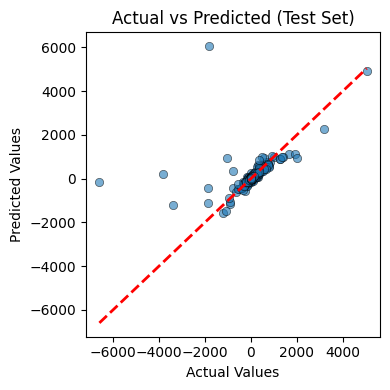

In [ ]:
# diagram actual vs predicted plot
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted (Test Set)')
plt.tight_layout()
plt.show()

In [ ]:
# implementasi aturan bisnis
THRESHOLD_DISKON_BESAR = 0.3

def keputusan_diskon(diskon, pred_profit):
  if diskon > THRESHOLD_DISKON_BESAR and pred_profit < 0:
      return "TOLAK"
  else:
      return "SETUJU"

## Linear Regression

In [ ]:
# konversi data ke numpy arrays
X_train = feature_train.to_numpy()
y_train = target_train.to_numpy().ravel()

X_test = feature_test.to_numpy()
y_test = target_test.to_numpy().ravel()

In [ ]:
linreg.coef_

array([ 2.91690157e-01, -4.12819077e+00, -1.50056585e+02,  1.24303921e+00,
       -3.69936745e+01,  4.22432163e+00,  3.27693529e+01, -1.60495530e+01,
        1.20901891e+01, -2.84456292e+00,  5.39953060e+01, -2.15880812e+01,
        2.83934314e+00,  2.40573010e+02,  9.15933882e+00,  1.49580252e-02,
        5.25388321e+01,  3.47646409e+00, -1.65819670e+02,  9.72048733e+00,
       -2.59344339e+01, -2.32522194e+01, -5.81356394e+01, -7.07837685e+01,
       -3.56709086e-01,  7.04458925e-01, -3.47749839e-01,  7.64062759e+00,
       -3.21307915e+00,  1.95334485e+00, -6.38089328e+00,  2.13650674e+00,
        5.93464805e-01,  9.46802058e-02,  1.10376148e-01, -2.18164161e+00,
       -6.18898556e+01, -8.77970835e+01])

In [ ]:
from sklearn.linear_model import LinearRegression

# define the model
linreg = LinearRegression()

# train the model
linreg.fit(X_train, y_train)

LinearRegression()

In [ ]:
# retrieve the coefficients
# show as a nice dataframe

data = feature_train
model = linreg

coef_df = pd.DataFrame({
    'feature':['intercept'] + data.columns.tolist(),
    'coefficient':[model.intercept_] + list(model.coef_)
})

coef_df

,feature,coefficient
0,intercept,-4287.012381
1,Sales,0.291690
2,Quantity,-4.128191
3,Discount,-150.056585
4,Ship_Mode,1.243039
5,Category_Furniture,-36.993675
6,Category_Office Supplies,4.224322
7,Category_Technology,32.769353
8,Sub-Category_Accessories,-16.049553
9,Sub-Category_Appliances,12.090189


In [ ]:
#nilai prediksi model
linreg.predict(X_train) [:10]

array([ 84.8691317 ,   5.54603313,  31.17016146,  77.10776417,
       -14.44711389,  35.43133199,  -8.31766087, -22.00707901,
       122.79629626, -14.92339394])

In [ ]:
#nilai target variabel sebenarnya
y_train[:10]

array([  6.47  ,   0.4074,   5.334 ,   4.7236,   6.8136,   6.74  ,
        13.078 ,  -7.7406, 257.9871,   0.8988])

In [ ]:
# model evaluation on training data
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# create prediction vector on training data
y_predict_train = linreg.predict(X_train)

print('MAE for traning data is {}'.format(mean_absolute_error(y_train, y_predict_train)))
print('MAPE for traning data is {}'.format(mean_absolute_percentage_error(y_train, y_predict_train)))

MAE for traning_data is 53.508447789584984
MAPE for traning_data is 2177435054121388.2


In [ ]:
# prepare prediction result on test data
X_admit_test = feature_test.to_numpy()
y_admit_test = target_test.to_numpy().ravel()

In [ ]:
# model evaluation on test data

# create prediction vector on training data
y_predict_test = linreg.predict(X_test)

print('MAE for test data is {}'.format(mean_absolute_error(y_test, y_predict_test)))
print('MAPE for test data is {}'.format(mean_absolute_percentage_error(y_test, y_predict_test)))

MAE for test data is 71.20178960725413
MAPE for test data is 634871627909946.2
